In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


In [14]:
tickers=["RELIANCE.NS", "TCS.NS", "INFY.NS"]

featured={}
for ticker in tickers:
    fname=ticker.replace(".","_")
    featured[ticker]=pd.read_csv(f"{fname}_features.csv")

#lets take one stock for example to display
df=featured['RELIANCE.NS']
print(df.head())

        Close  trend_sma_fast  trend_sma_slow  trend_ema_fast  trend_macd  \
0  500.025238      489.756029      489.756029      491.268917   -1.364765   
1  502.791748      490.842339      490.842339      493.041661   -0.344471   
2  502.149811      491.338458      491.712144      494.442915    0.407622   
3  524.237427      494.213750      494.035379      499.026686    2.754198   
4  547.852234      499.560443      497.623169      506.538308    6.445098   

   trend_macd_signal  trend_macd_diff  momentum_rsi  volatility_bbh  \
0          -1.647040         0.282275     62.383428      498.955612   
1          -1.386526         1.042055     65.606458      502.222264   
2          -1.027697         1.435318     64.231225      504.196371   
3          -0.271318         3.025515     79.868210      514.660342   
4           1.071965         5.373133     86.608705      531.057810   

   volatility_bbl  volatility_bbw  volatility_atr  volume_obv  return_1d  \
0      480.556445        3.756803 

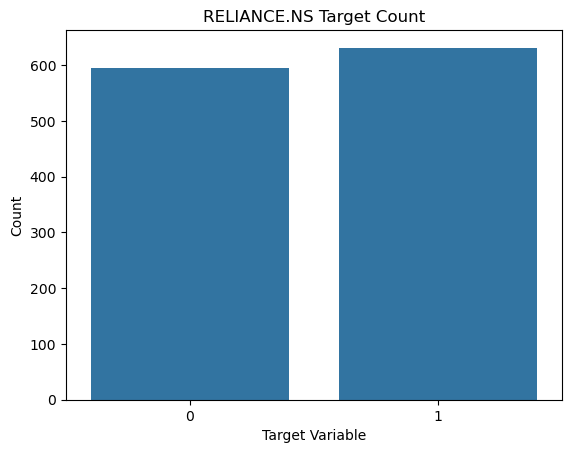

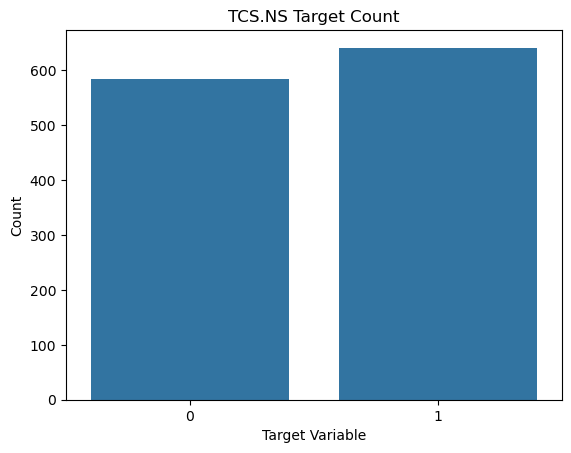

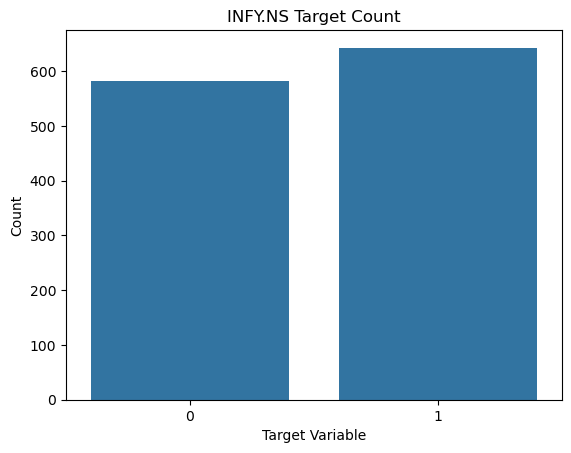

In [18]:
# Target feature count
for ticker in tickers:
    data=featured[ticker]
    sns.countplot(data=data,x='Target')
    plt.title(f"{ticker} Target Count")
    plt.xlabel("Target Variable")
    plt.ylabel("Count")
    plt.show()

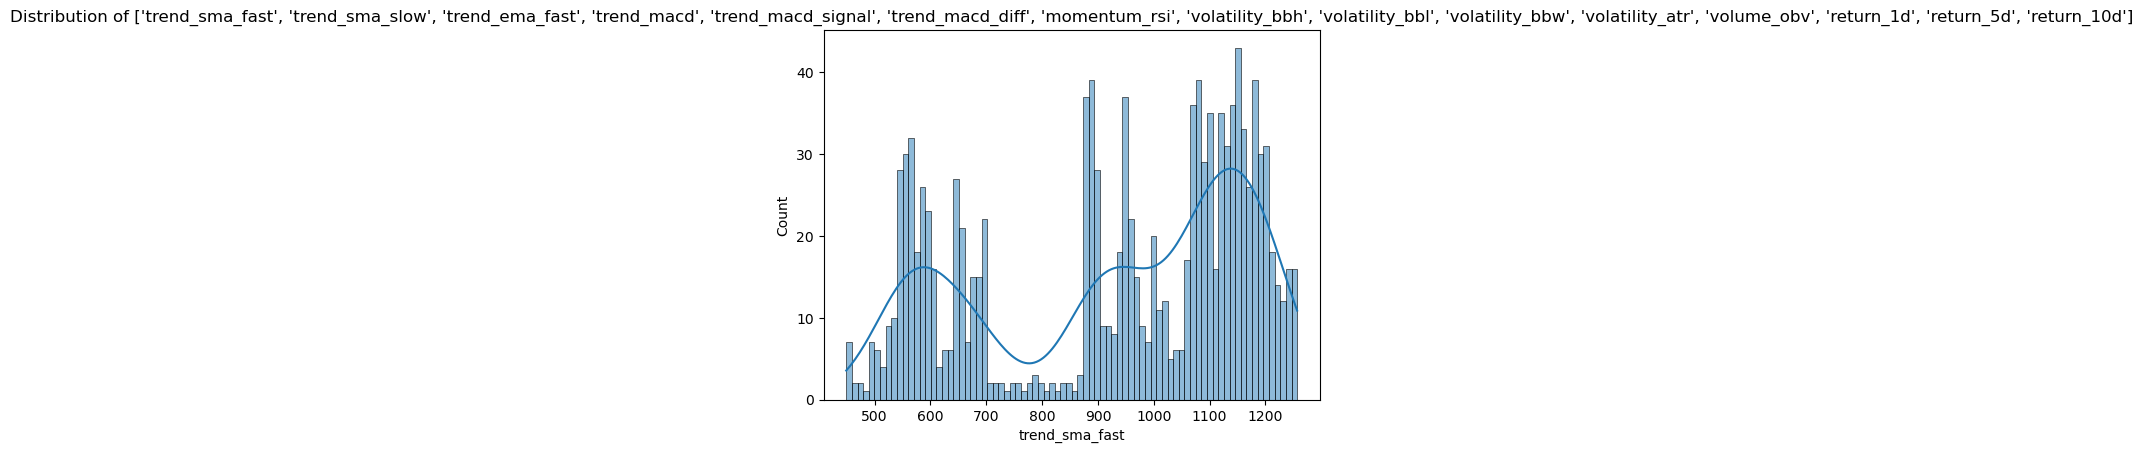

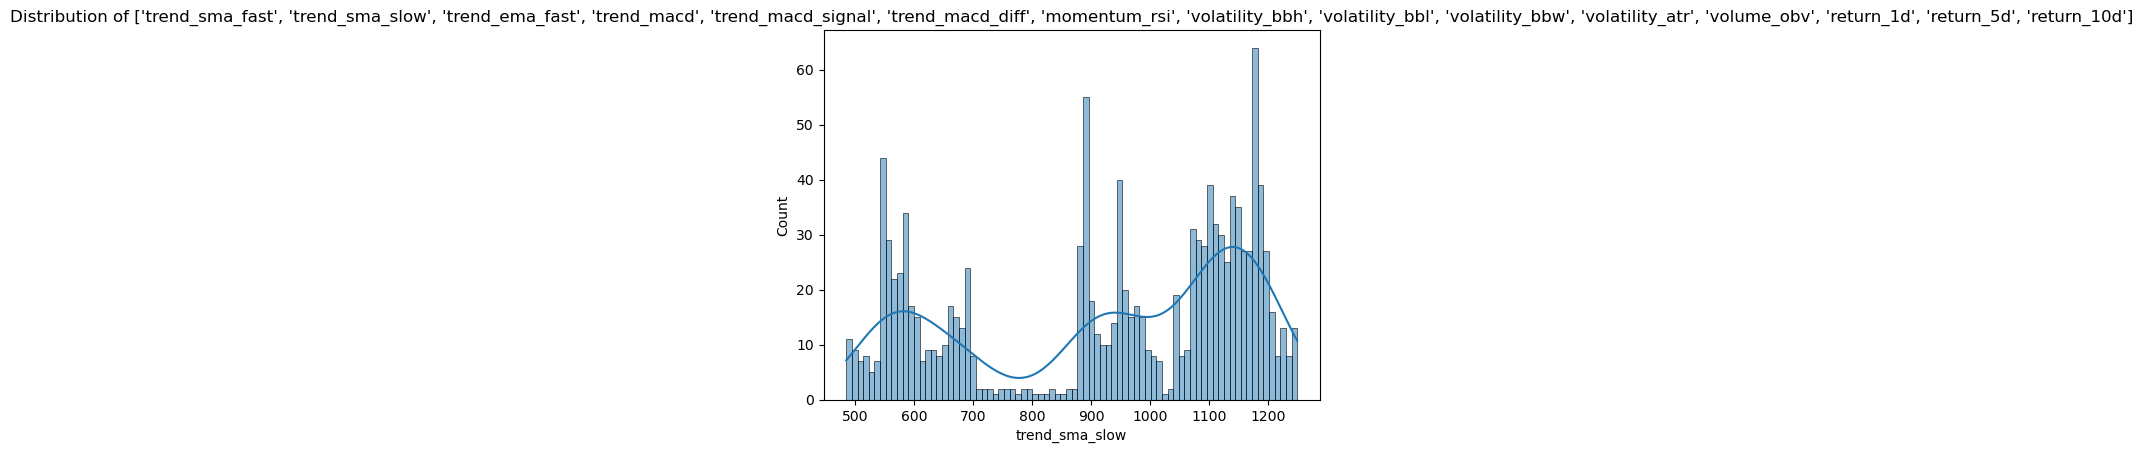

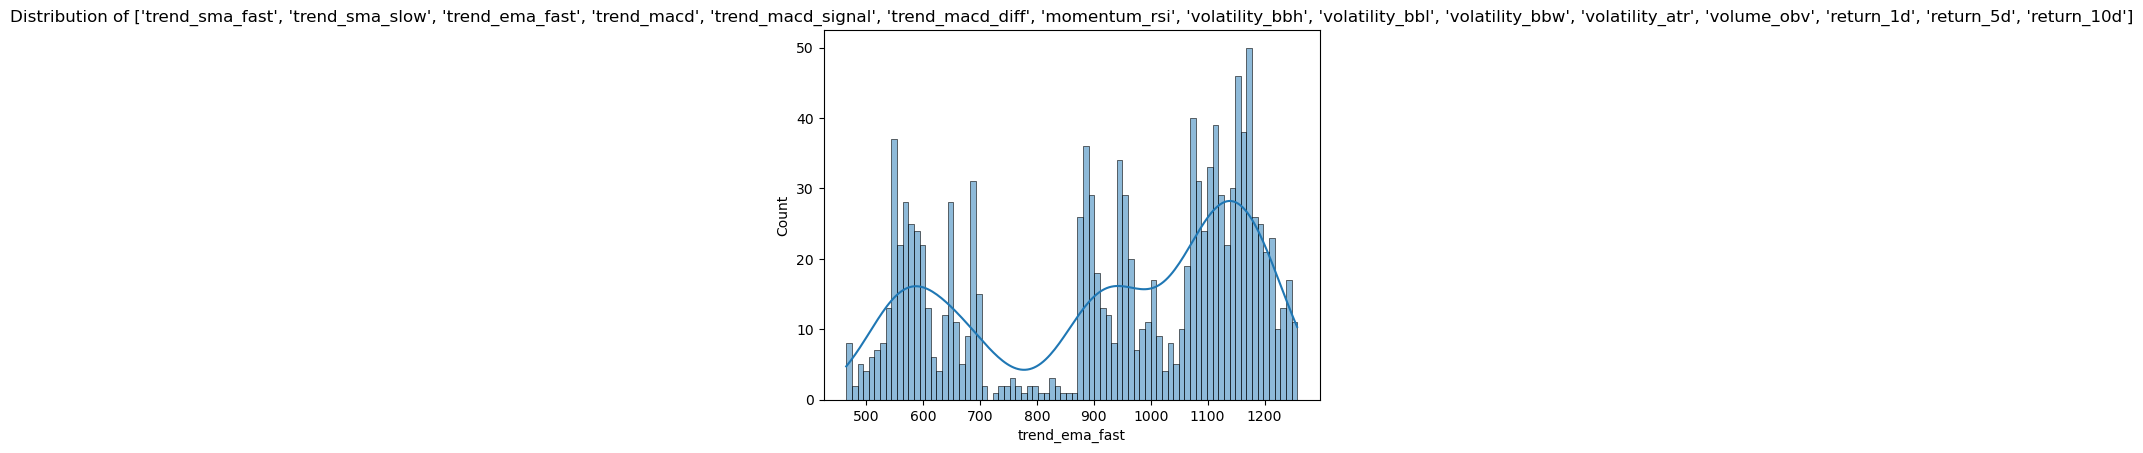

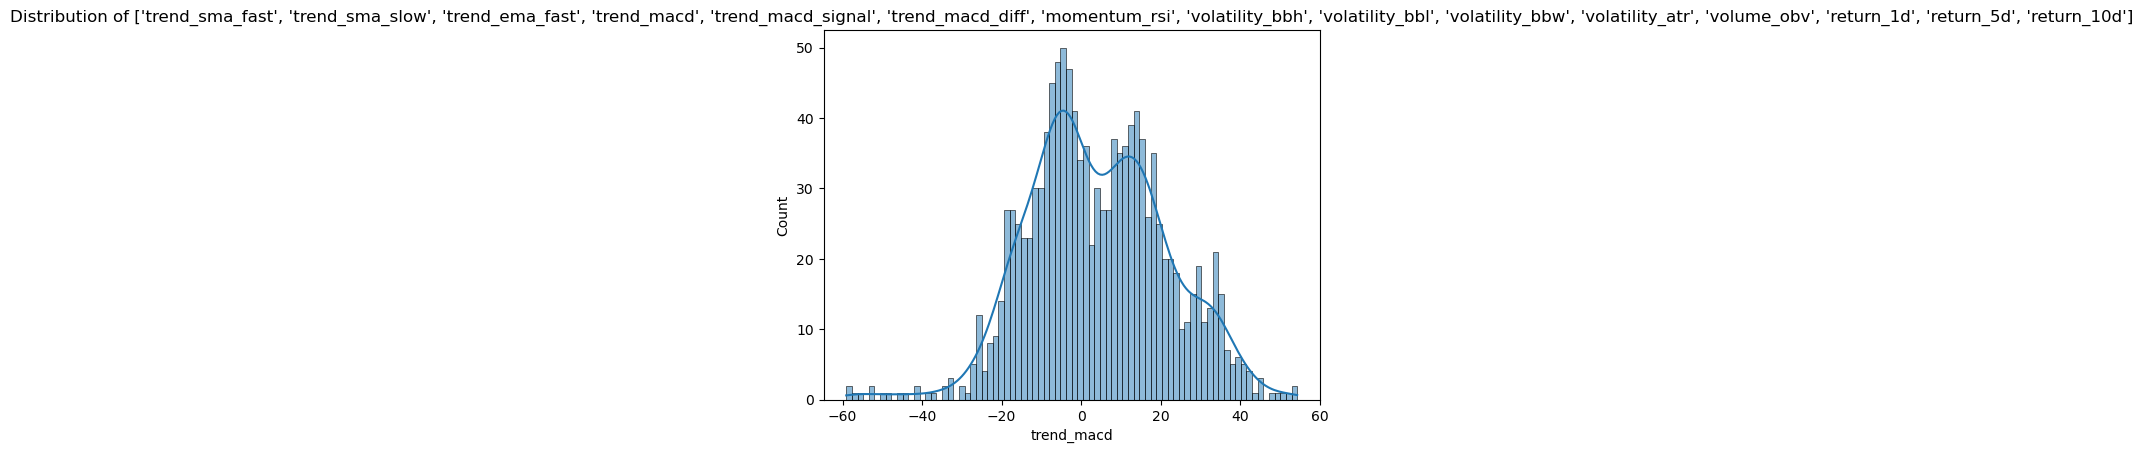

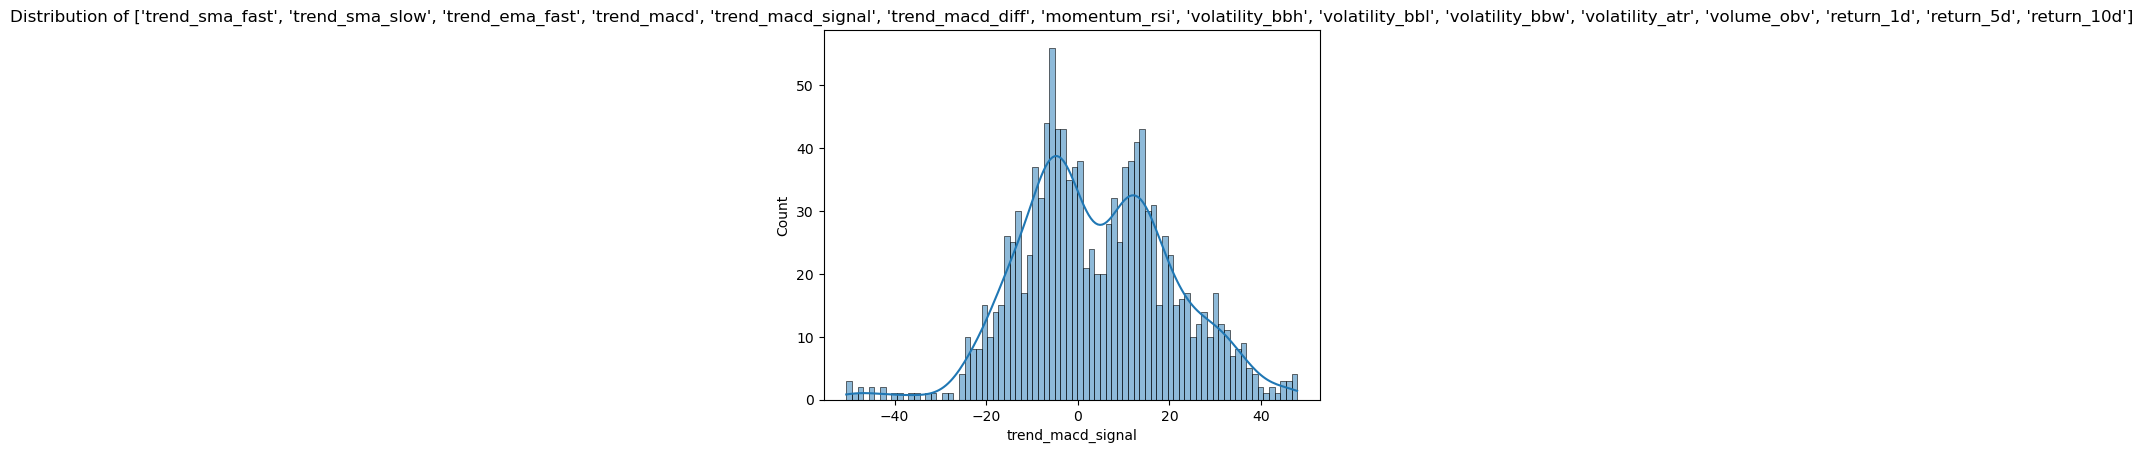

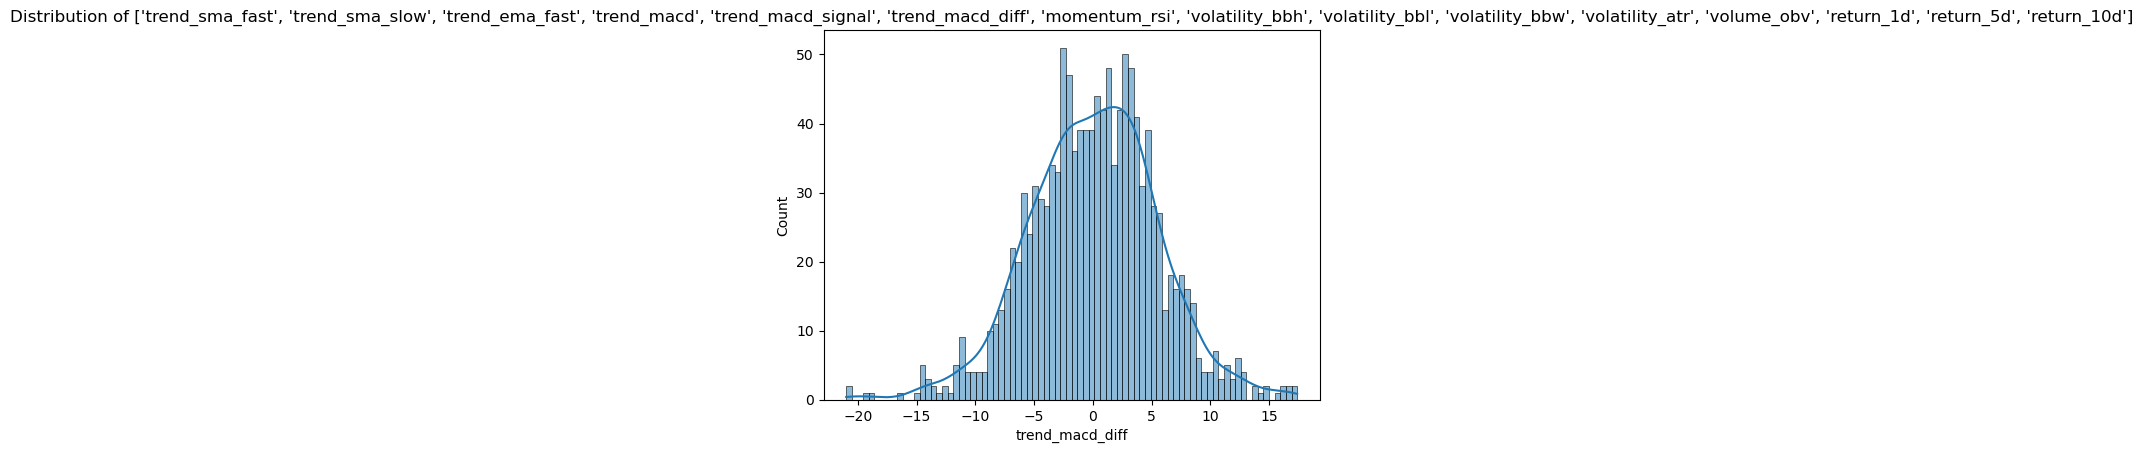

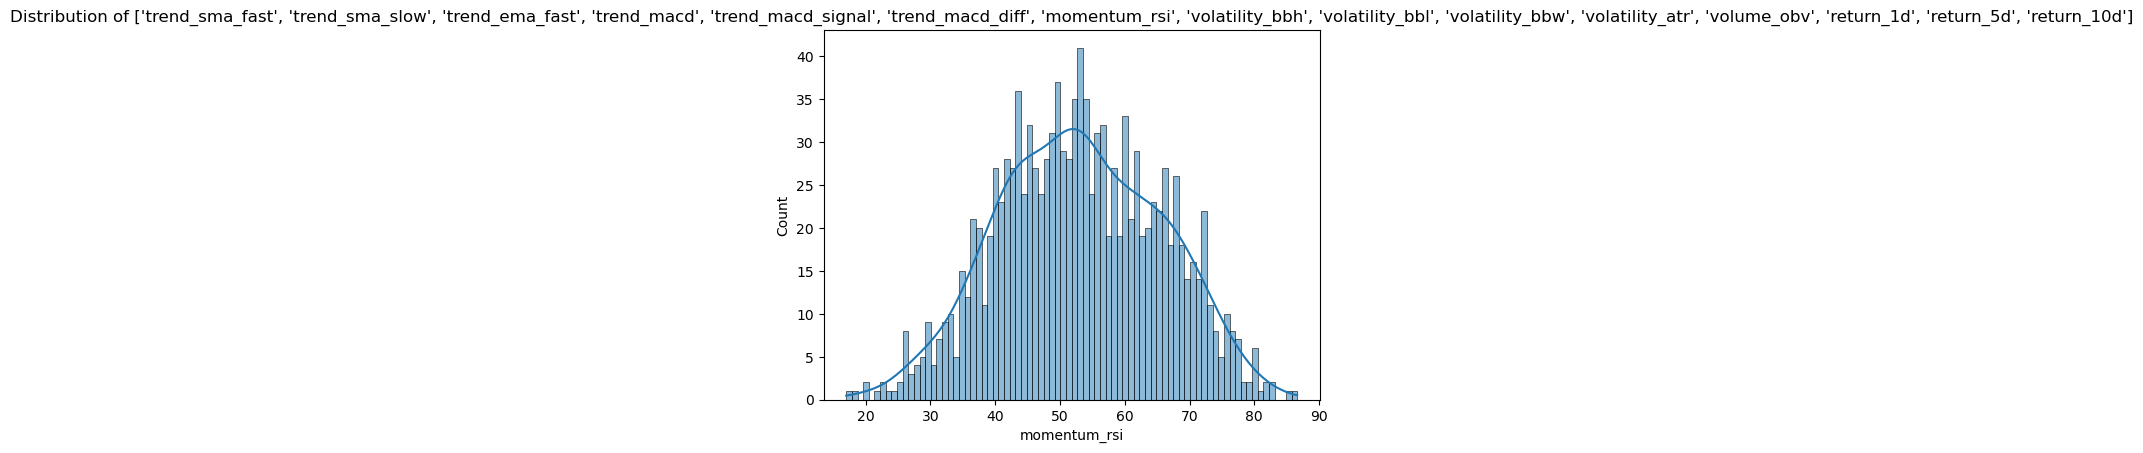

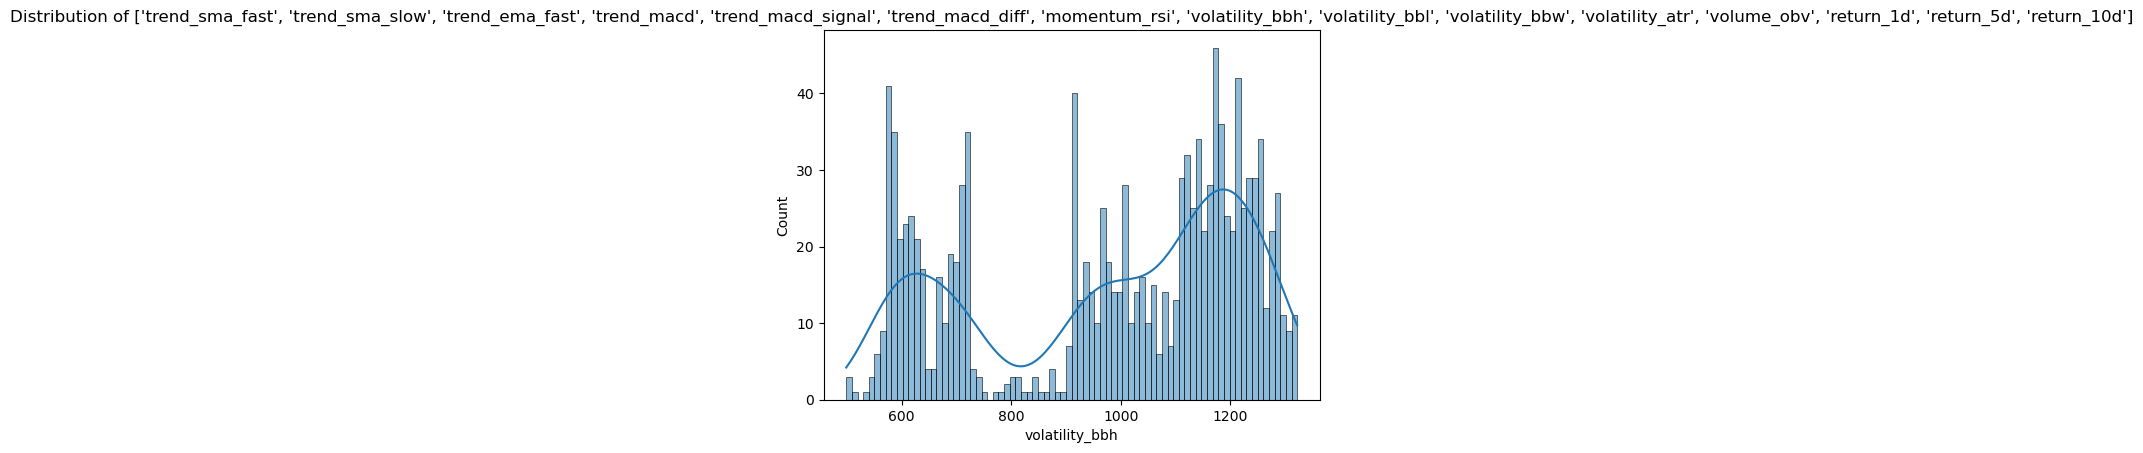

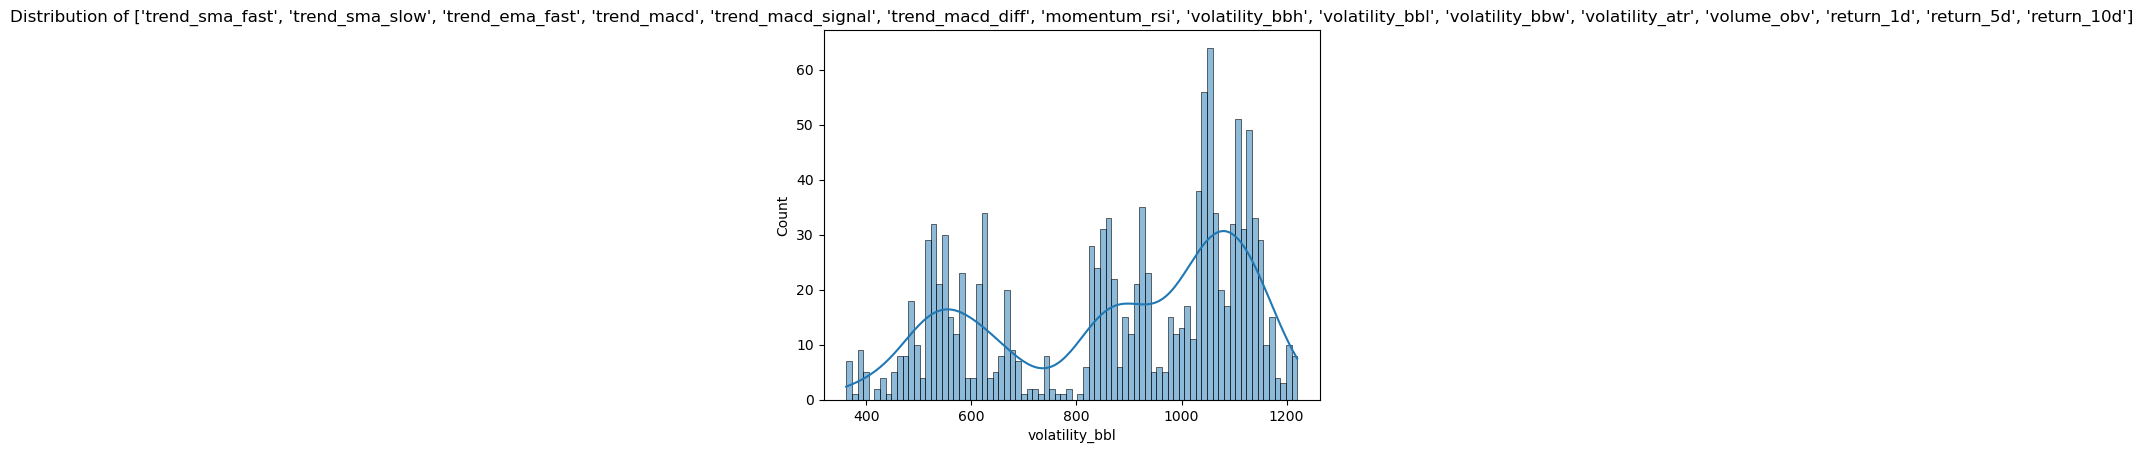

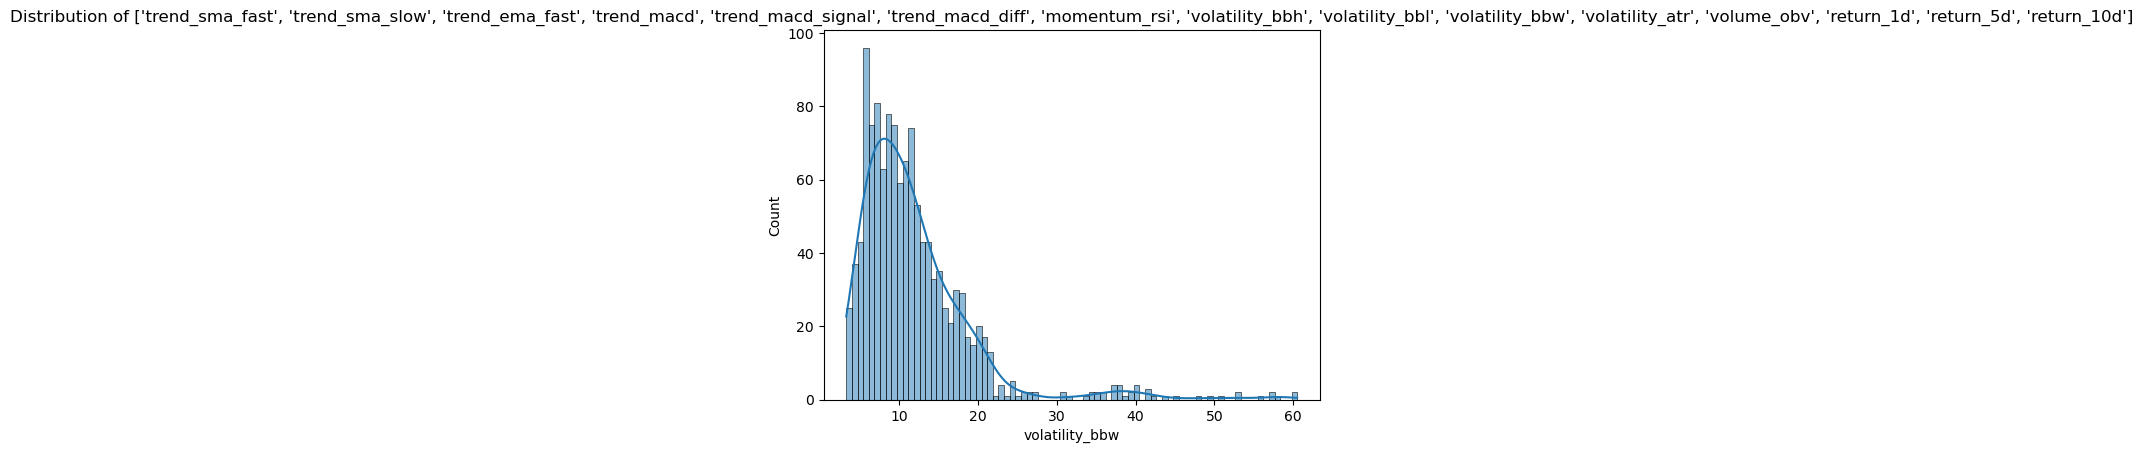

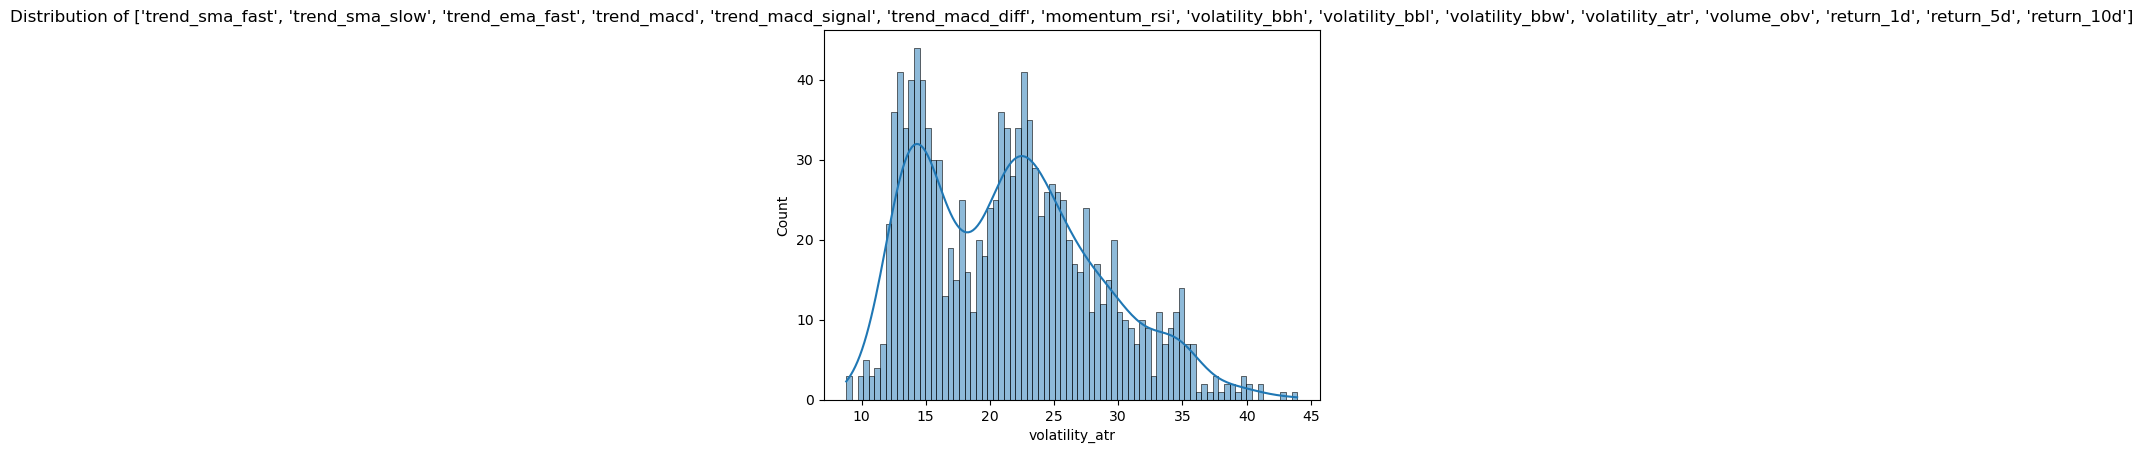

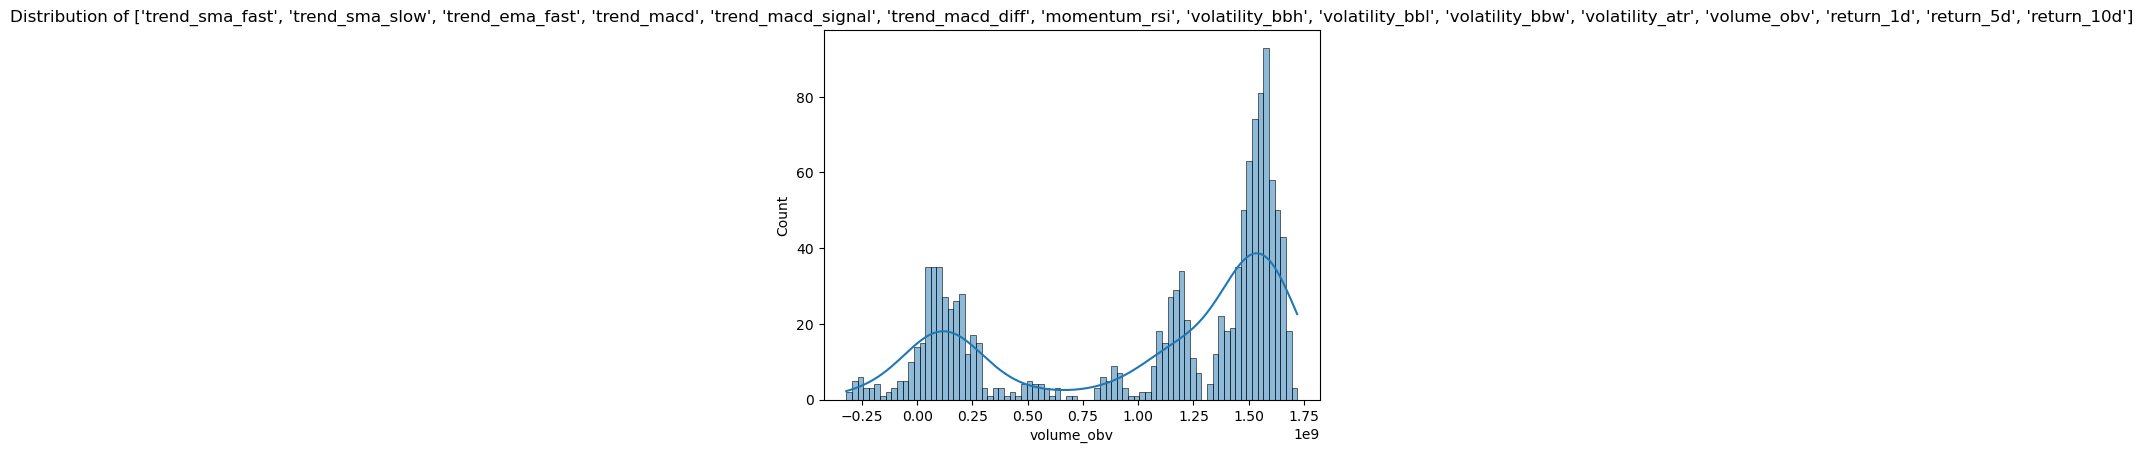

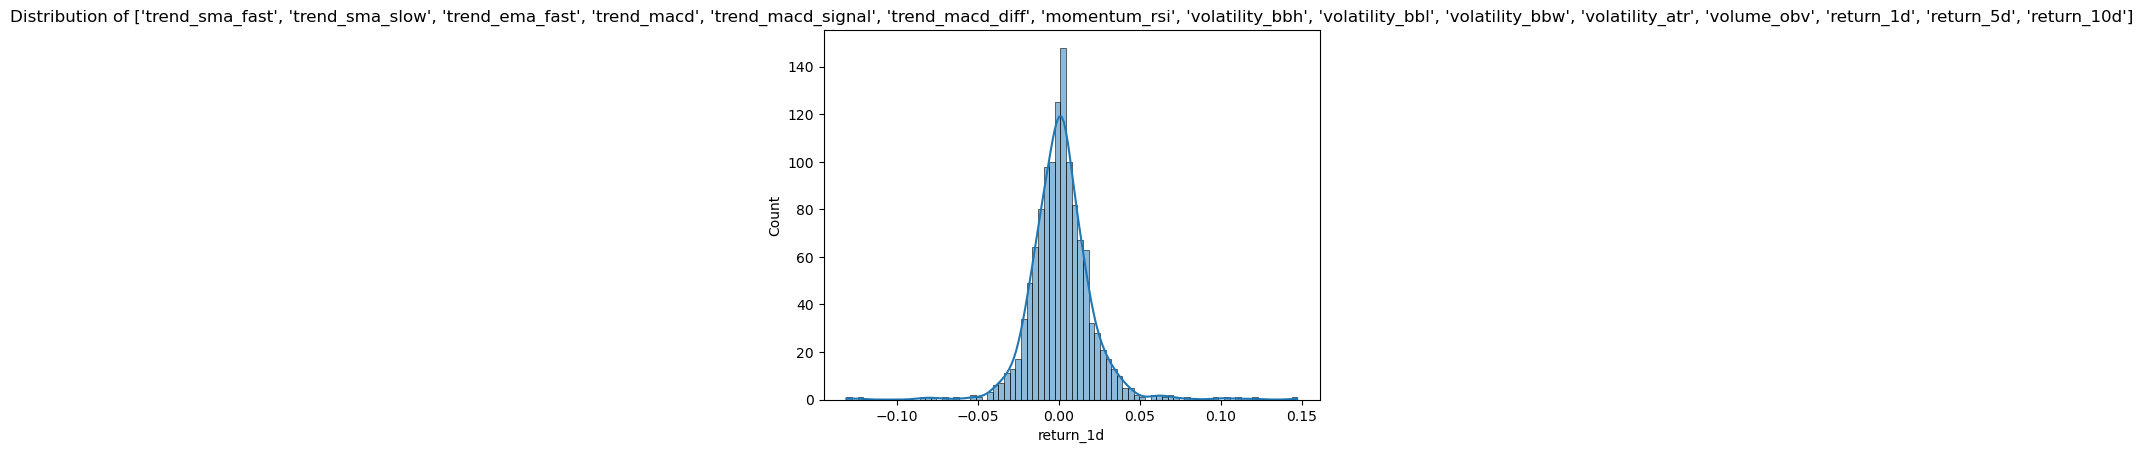

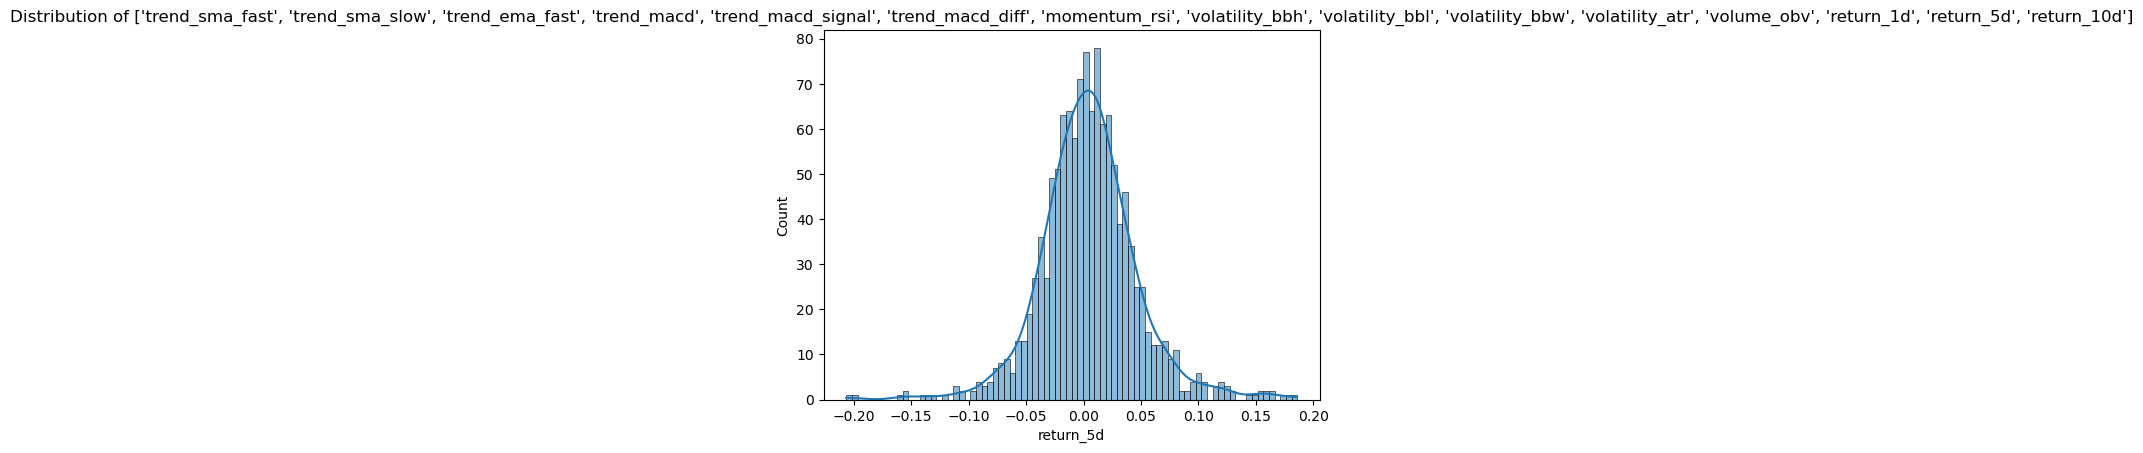

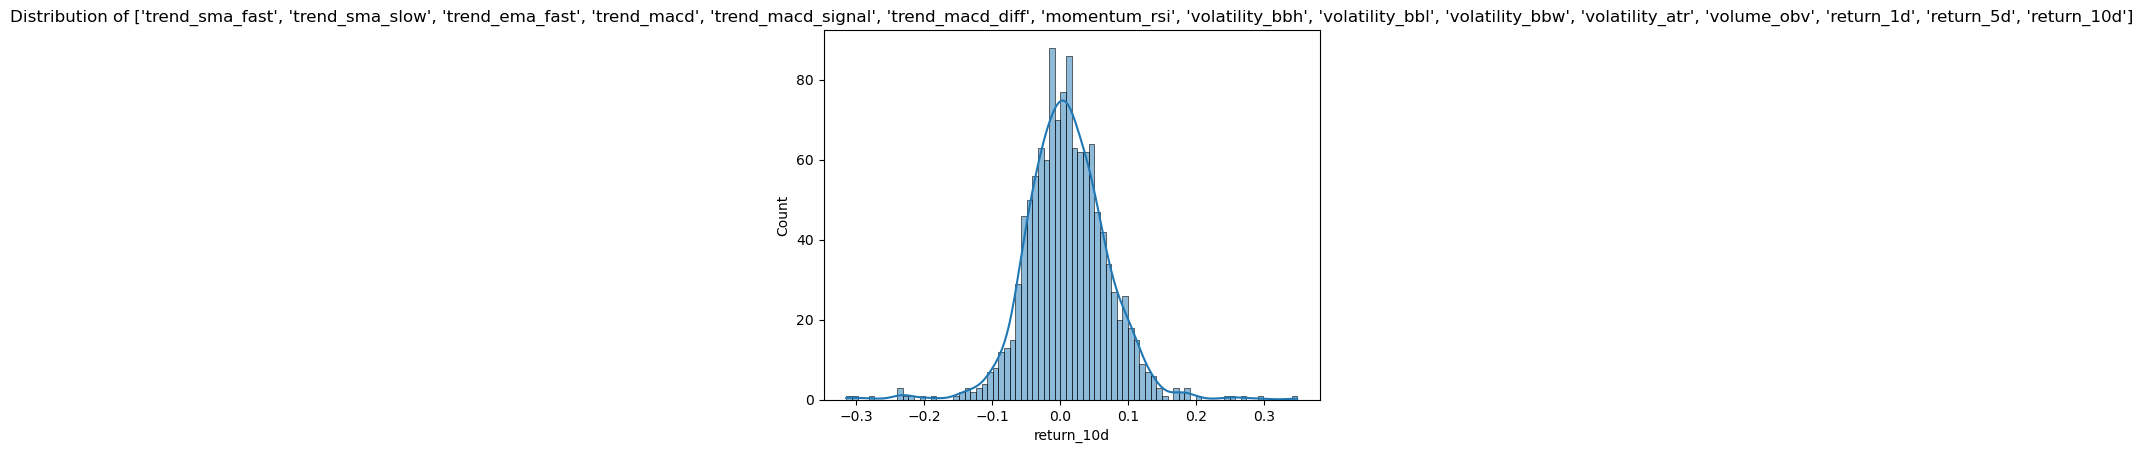

In [26]:
#feature distribution for reliance.ns (using one stock for simplicity)

features=[col for col in df.columns if col not in ['Close', 'Target']]
for feature in features:
    sns.histplot(data=df,x=feature,bins=80,kde=True)
    plt.title(f"Distribution of {features}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Count")
    plt.show()

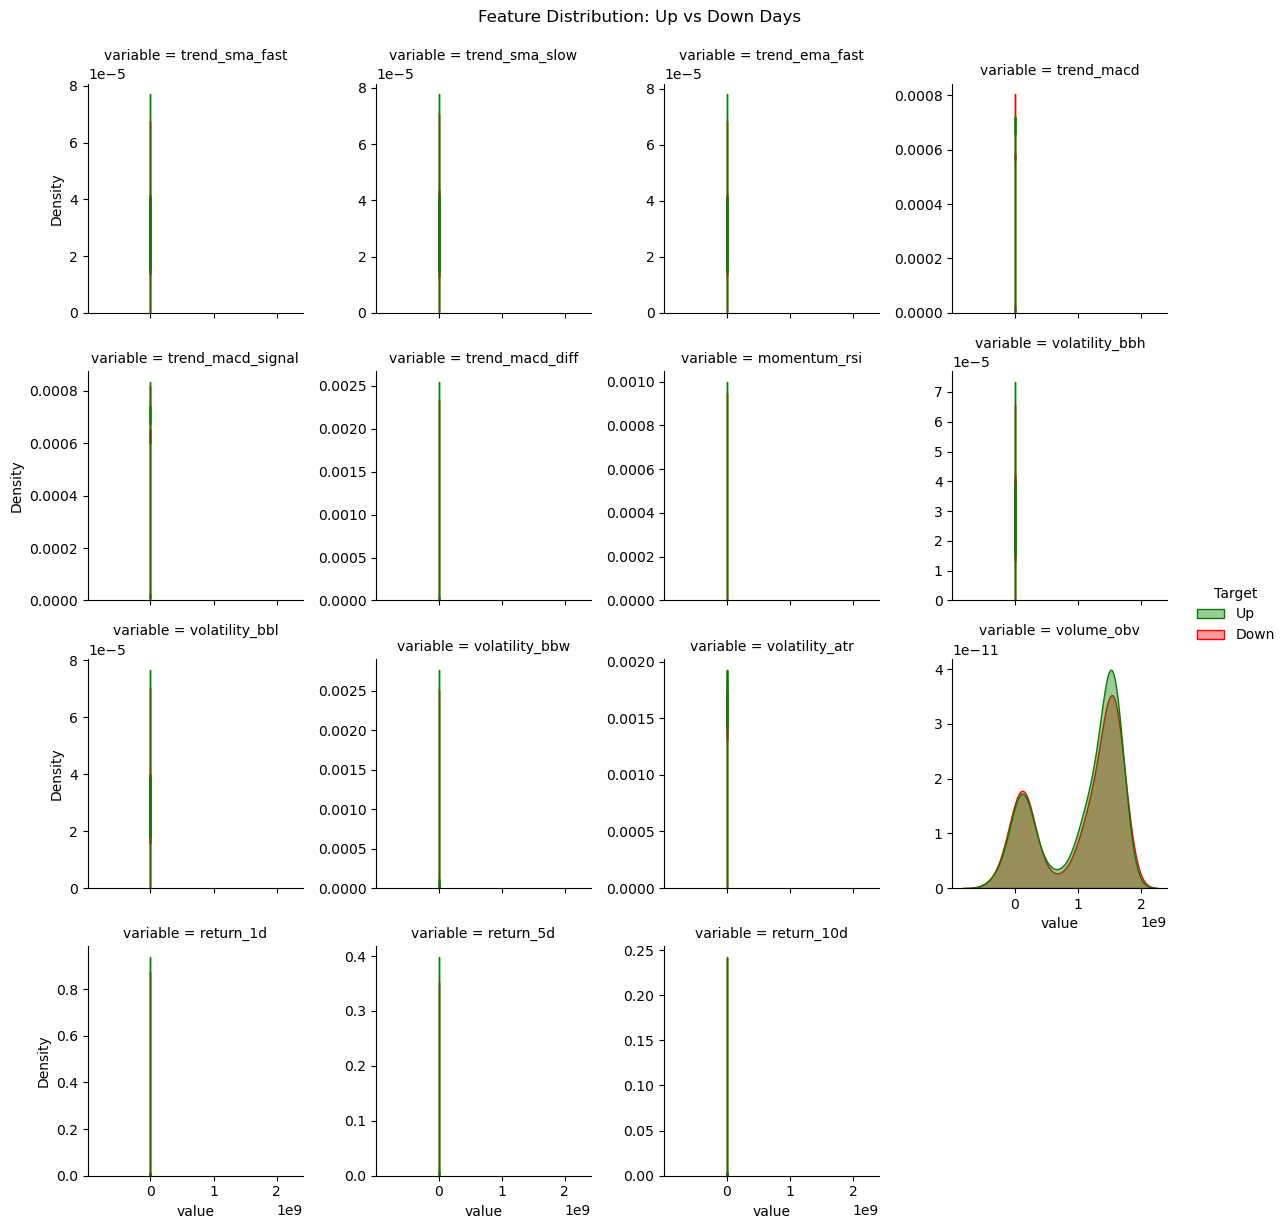

In [30]:
#Feature vs Target (Up vs Down)

# 1. Clean data prep (chaining replace and melt is often cleaner)
df_melt = df[features + ['Target']].replace({'Target': {1: 'Up', 0: 'Down'}}).melt(id_vars='Target')

sns.displot(
    data=df_melt, x='value', hue='Target', col='variable', 
    kind='kde', fill=True, col_wrap=4, height=3, 
    palette={'Up': 'green', 'Down': 'red'},
    facet_kws={'sharey': False}, alpha=0.4
).fig.suptitle("Feature Distribution: Up vs Down Days", y=1.02)

plt.show()

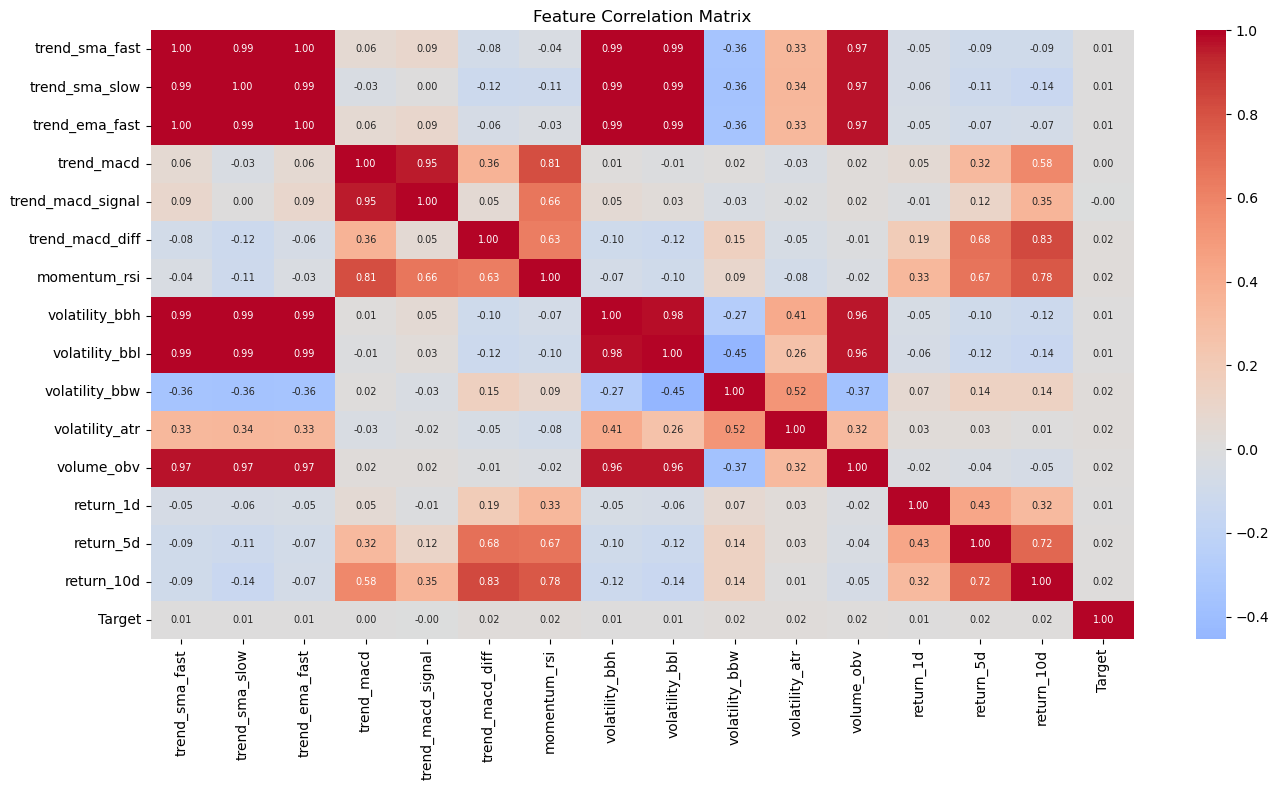

In [32]:
plt.figure(figsize=(14, 8))
sns.heatmap(df[features + ['Target']].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, annot_kws={"size": 7})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

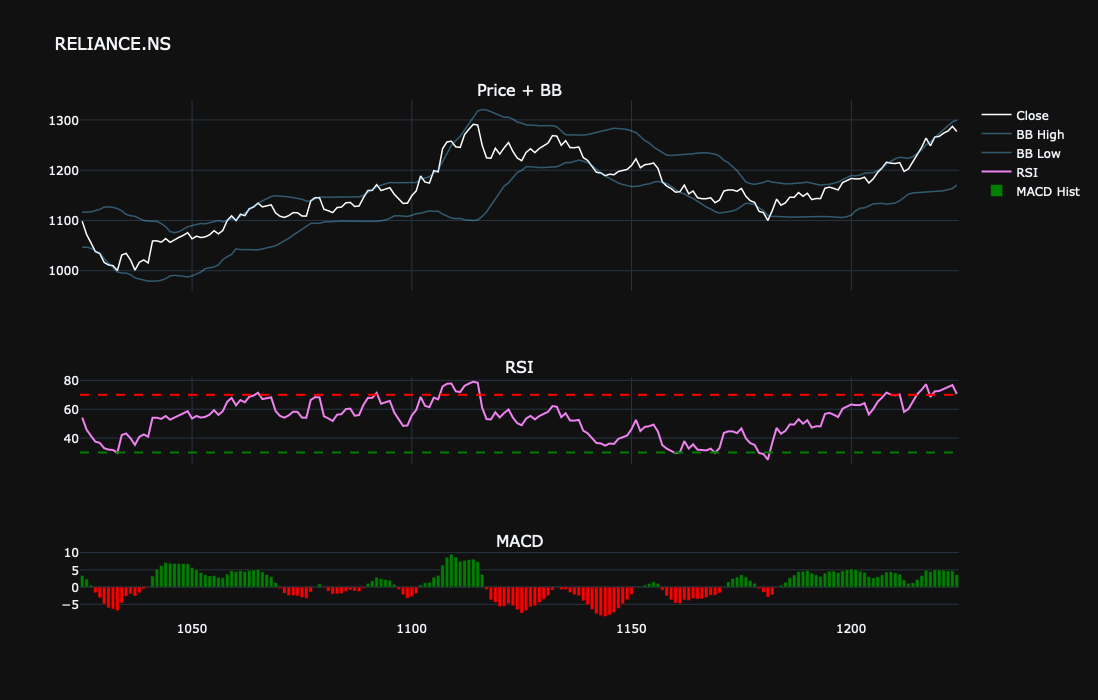

In [38]:
def plot_indicators(df, ticker, n=200):
    d = df.tail(n)
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        row_heights=[0.55, 0.25, 0.20],
                        subplot_titles=['Price + BB', 'RSI', 'MACD'])

    # Price + Bollinger Bands
    for col, color, name in [
        ('Close',              'white',  'Close'),
        ('volatility_bbh',     'rgba(100,200,255,0.4)', 'BB High'),
        ('volatility_bbl',     'rgba(100,200,255,0.4)', 'BB Low'),
    ]:
        fig.add_trace(go.Scatter(x=d.index, y=d[col], name=name,
                      line=dict(color=color, width=1.5)), row=1, col=1)

    # RSI
    fig.add_trace(go.Scatter(x=d.index, y=d['momentum_rsi'],
                  name='RSI', line=dict(color='violet')), row=2, col=1)
    fig.add_hline(y=70, line_dash='dash', line_color='red',   row=2, col=1)
    fig.add_hline(y=30, line_dash='dash', line_color='green', row=2, col=1)

    # MACD
    colors = ['green' if v >= 0 else 'red' for v in d['trend_macd_diff']]
    fig.add_trace(go.Bar(x=d.index, y=d['trend_macd_diff'],
                  marker_color=colors, name='MACD Hist'), row=3, col=1)

    fig.update_layout(height=700,template='plotly_dark',
                      title=ticker, xaxis_rangeslider_visible=False)
    fig.show()

plot_indicators(df, "RELIANCE.NS")